Распаковано в папку 'dataset'
Найдено файлов аннотаций: 7035
head: 6677
helmet: 19747
person: 615


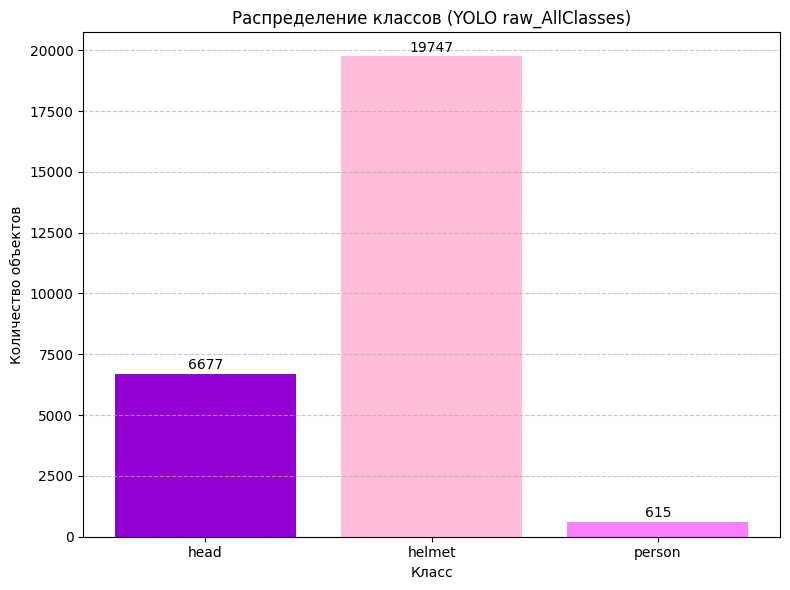

In [4]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import yaml  # для чтения data.yaml (если есть)


zip_name = "Hard Hat Workers.v10-raw_allclasses.yolov8.zip"
!unzip -q "{zip_name}" -d dataset
print("Распаковано в папку 'dataset'")

DATASET_DIR = 'dataset'

# Ищем все .txt файлы (обычно в папках labels)
label_files = []
for root, dirs, files in os.walk(DATASET_DIR):
    for f in files:
        if f.endswith('.txt') and 'labels' in root:  # проверяем, что это папка labels
            label_files.append(os.path.join(root, f))

if not label_files:
    raise FileNotFoundError("Не найдено .txt файлов с аннотациями. Проверьте, что архив содержит папки train/valid/test/labels.")

print(f"Найдено файлов аннотаций: {len(label_files)}")

# ----- Определяем имена классов -----
# Сначала пытаемся найти data.yaml
class_names = None
for root, dirs, files in os.walk(DATASET_DIR):
    if 'data.yaml' in files:
        yaml_path = os.path.join(root, 'data.yaml')
        with open(yaml_path, 'r') as f:
            data = yaml.safe_load(f)
            class_names = data.get('names', [])
        break

# Если data.yaml нет, используем жёсткую привязку (порядок из raw_AllClasses на Roboflow)
if class_names is None:
    print("Внимание: data.yaml не найден, используется фиксированный порядок классов")
    class_names = {0: 'head', 1: 'helmet', 2: 'person'}  # уточните, если у вас иначе
elif isinstance(class_names, list):
    # Превращаем список в словарь {индекс: имя}
    class_names = {i: name for i, name in enumerate(class_names)}

# ----- Подсчёт объектов -----
class_counter = Counter()

for file_path in label_files:
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:  # class xc yc w h
                cls_id = int(parts[0])
                class_counter[cls_id] += 1

# Сопоставляем id с именами
named_counter = {class_names.get(cid, str(cid)): cnt for cid, cnt in class_counter.items()}

# Печать чисел
for name, cnt in sorted(named_counter.items()):
    print(f"{name}: {cnt}")

# ----- Построение графика -----
classes = sorted(named_counter.keys())
counts = [named_counter[cls] for cls in classes]

plt.figure(figsize=(8, 6))
colors = ['#9400d3', '#ffbcd9', '#fb7efd'][:len(classes)]
bars = plt.bar(classes, counts, color=colors)
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.title('Распределение классов (YOLO raw_AllClasses)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, cnt in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
             str(cnt), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [5]:
import os
import shutil
import hashlib
from tqdm import tqdm

# ------------------------------------------------------------
# 1. Распаковка вашего архива
# ------------------------------------------------------------
ZIP_FILE = "Hard Hat Workers.v10-raw_allclasses.yolov8.zip"
ORIGINAL_DIR = 'dataset'

if not os.path.exists(ORIGINAL_DIR):
    print(f"Распаковываем {ZIP_FILE} ...")
    !unzip -q "{ZIP_FILE}" -d {ORIGINAL_DIR}
    print(f"✅ Готово: данные в папке '{ORIGINAL_DIR}'")
else:
    print(f"Папка '{ORIGINAL_DIR}' уже существует, распаковка не требуется.")

# ------------------------------------------------------------
# 2. Создание резервной копии и рабочей папки
# ------------------------------------------------------------
BACKUP_DIR = 'dataset_backup'
WORK_DIR   = 'dataset_clean'

if not os.path.exists(BACKUP_DIR):
    print(f"Создаём резервную копию {ORIGINAL_DIR} -> {BACKUP_DIR} ...")
    shutil.copytree(ORIGINAL_DIR, BACKUP_DIR)
    print("✅ Резервная копия создана.")
else:
    print(f"Резервная копия уже существует: {BACKUP_DIR}")

if not os.path.exists(WORK_DIR):
    print(f"Создаём рабочую копию {ORIGINAL_DIR} -> {WORK_DIR} ...")
    shutil.copytree(ORIGINAL_DIR, WORK_DIR)
    print("✅ Рабочая копия создана.")
else:
    print(f"Рабочая копия уже существует: {WORK_DIR}")

# ------------------------------------------------------------
# 3. Поиск дубликатов в рабочей копии (dry_run)
# ------------------------------------------------------------
def find_images(directory, extensions=('.jpg', '.jpeg', '.png')):
    for root, dirs, files in os.walk(directory):
        for f in files:
            if f.lower().endswith(extensions):
                yield os.path.join(root, f)

hashes = {}
duplicates = []

print(f"\nСканируем рабочую папку: {WORK_DIR}")
for img_path in tqdm(list(find_images(WORK_DIR)), desc="Поиск дубликатов"):
    with open(img_path, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    if file_hash in hashes:
        duplicates.append(img_path)
    else:
        hashes[file_hash] = img_path

if not duplicates:
    print("\n✅ Дубликаты не найдены — датасет чист.")
else:
    print(f"\n🔍 Найдено дубликатов: {len(duplicates)}")
    print("Первые 10 дубликатов (будут удалены при реальном запуске):")
    for dup in duplicates[:10]:
        print("  -", dup)
    print("\n⚠️ Пока ничего не удалено. Чтобы удалить, запустите следующую ячейку с REMOVE=True")

Папка 'dataset' уже существует, распаковка не требуется.
Создаём резервную копию dataset -> dataset_backup ...
✅ Резервная копия создана.
Создаём рабочую копию dataset -> dataset_clean ...
✅ Рабочая копия создана.

Сканируем рабочую папку: dataset_clean


Поиск дубликатов: 100%|██████████| 7035/7035 [00:01<00:00, 5248.29it/s]


✅ Дубликаты не найдены — датасет чист.


In [6]:
# ============================================================
# ПОЛНЫЙ ЦИКЛ ОЧИСТКИ ДАТАСЕТА: дубликаты + низкое качество
# ============================================================
import os
import shutil
import hashlib
import cv2
import numpy as np
from tqdm import tqdm

# --- НАСТРОЙКИ (можно менять) ---
ZIP_FILE = "Hard Hat Workers.v10-raw_allclasses.yolov8.zip"
ORIGINAL_DIR = 'dataset'
BACKUP_DIR = 'dataset_backup'
WORK_DIR = 'dataset_clean'

# Параметры для фильтрации качества
MIN_DIM = 100                # минимальная сторона в пикселях (меньше — удаляем)
LAPLACIAN_THRESHOLD = 50    # порог чёткости (чем меньше, тем более размытое)

REMOVE = False   # ❗ Пока False — только покажет, что будет удалено
                 # Поменяйте на True для реального удаления

# ============================================================
# 1. РАСПАКОВКА ZIP (если ещё не распакован)
# ============================================================
if not os.path.exists(ORIGINAL_DIR):
    print(f"📦 Распаковываем {ZIP_FILE} ...")
    !unzip -q "{ZIP_FILE}" -d {ORIGINAL_DIR}
    print(f"✅ Данные распакованы в '{ORIGINAL_DIR}'")
else:
    print(f"📁 Папка '{ORIGINAL_DIR}' уже существует, пропускаем распаковку.")

# ============================================================
# 2. СОЗДАНИЕ РЕЗЕРВНОЙ И РАБОЧЕЙ КОПИЙ
# ============================================================
if not os.path.exists(BACKUP_DIR):
    print(f"💾 Создаём резервную копию {ORIGINAL_DIR} -> {BACKUP_DIR} ...")
    shutil.copytree(ORIGINAL_DIR, BACKUP_DIR)
    print("✅ Резервная копия готова.")
else:
    print(f"💾 Резервная копия уже существует: {BACKUP_DIR}")

if not os.path.exists(WORK_DIR):
    print(f"📋 Создаём рабочую копию {ORIGINAL_DIR} -> {WORK_DIR} ...")
    shutil.copytree(ORIGINAL_DIR, WORK_DIR)
    print("✅ Рабочая копия готова.")
else:
    print(f"📋 Рабочая копия уже существует: {WORK_DIR}")

# ============================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================
def find_images(directory, extensions=('.jpg', '.jpeg', '.png')):
    """Генератор путей ко всем изображениям в directory."""
    for root, dirs, files in os.walk(directory):
        for f in files:
            if f.lower().endswith(extensions):
                yield os.path.join(root, f)

def image_quality_check(img_path):
    """Проверка качества: достаточный размер и резкость."""
    img = cv2.imread(img_path)
    if img is None:
        return False, "нечитаемое"
    h, w = img.shape[:2]
    if h < MIN_DIM or w < MIN_DIM:
        return False, f"маленькое ({w}x{h})"
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    if laplacian_var < LAPLACIAN_THRESHOLD:
        return False, f"размытое (lap={laplacian_var:.1f})"
    return True, ""

# ============================================================
# 3. ПОИСК И УДАЛЕНИЕ ДУБЛИКАТОВ
# ============================================================
print("\n🔎 Шаг 1: Поиск дубликатов...")
hashes = {}
duplicates = []
all_images = list(find_images(WORK_DIR))

for img_path in tqdm(all_images, desc="Сканирование на дубликаты"):
    with open(img_path, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    if file_hash in hashes:
        duplicates.append(img_path)
    else:
        hashes[file_hash] = img_path

if not duplicates:
    print("✅ Дубликаты не найдены.")
else:
    print(f"🔍 Найдено дубликатов: {len(duplicates)}")
    if REMOVE:
        for dup in tqdm(duplicates, desc="Удаление дубликатов"):
            os.remove(dup)
            # удаляем соответствующий .txt
            label_path = dup.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
            if os.path.exists(label_path):
                os.remove(label_path)
        print(f"✅ Удалено {len(duplicates)} дубликатов.")
    else:
        print("⚠️ Режим просмотра (REMOVE=False). Дубликаты НЕ удалены.")
        print("Примеры дубликатов (первые 5):")
        for d in duplicates[:5]:
            print("   ", d)

# ============================================================
# 4. ПОИСК И УДАЛЕНИЕ НИЗКОКАЧЕСТВЕННЫХ ИЗОБРАЖЕНИЙ
# ============================================================
print("\n🔎 Шаг 2: Проверка качества изображений...")
low_quality = []

# После удаления дубликатов пересканируем рабочую папку (могли удалиться)
current_images = list(find_images(WORK_DIR))
for img_path in tqdm(current_images, desc="Проверка качества"):
    ok, reason = image_quality_check(img_path)
    if not ok:
        low_quality.append((img_path, reason))

if not low_quality:
    print("✅ Все изображения прошли проверку качества.")
else:
    print(f"🔍 Найдено низкокачественных: {len(low_quality)}")
    if REMOVE:
        for (img_path, _) in tqdm(low_quality, desc="Удаление низкокачественных"):
            os.remove(img_path)
            label_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
            if os.path.exists(label_path):
                os.remove(label_path)
        print(f"✅ Удалено {len(low_quality)} низкокачественных изображений.")
    else:
        print("⚠️ Режим просмотра (REMOVE=False). Изображения НЕ удалены.")
        print("Примеры (первые 5):")
        for path, reason in low_quality[:5]:
            print(f"   {path}  ({reason})")

print("\n🏁 Готово! Рабочая копия лежит в папке:", WORK_DIR)
if not REMOVE:
    print("❗ Для реального удаления установите REMOVE = True и запустите ячейку снова.")

📁 Папка 'dataset' уже существует, пропускаем распаковку.
💾 Резервная копия уже существует: dataset_backup
📋 Рабочая копия уже существует: dataset_clean

🔎 Шаг 1: Поиск дубликатов...


Сканирование на дубликаты: 100%|██████████| 7035/7035 [00:00<00:00, 8114.46it/s]


✅ Дубликаты не найдены.

🔎 Шаг 2: Проверка качества изображений...


Проверка качества: 100%|██████████| 7035/7035 [00:21<00:00, 322.10it/s]

✅ Все изображения прошли проверку качества.

🏁 Готово! Рабочая копия лежит в папке: dataset_clean
❗ Для реального удаления установите REMOVE = True и запустите ячейку снова.
